In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
from google.colab import files

uploaded = files.upload()


Saving weatherAUS.csv to weatherAUS.csv


In [2]:

df = pd.read_csv("../../data/weatherAUS.csv")

print("Shape :", df.shape)
df.head()
df.info()
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

Shape : (145460, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am

Distribution de la variable cible ( RainTomorrow)

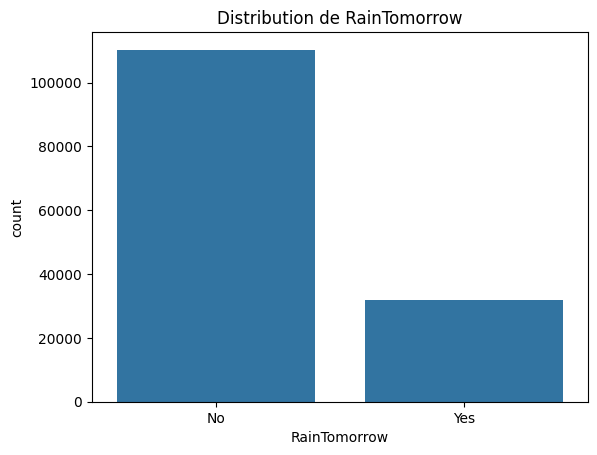

In [3]:
sns.countplot(x="RainTomorrow", data=df)
plt.title("Distribution de RainTomorrow")
plt.show()


In [4]:
df["RainTomorrow"].value_counts(normalize=True) * 100


RainTomorrow
No     77.581878
Yes    22.418122
Name: proportion, dtype: float64

Dataset déséquilibrée : la majorité de jours sans pluie 77%

Distribution des variables quantitatives

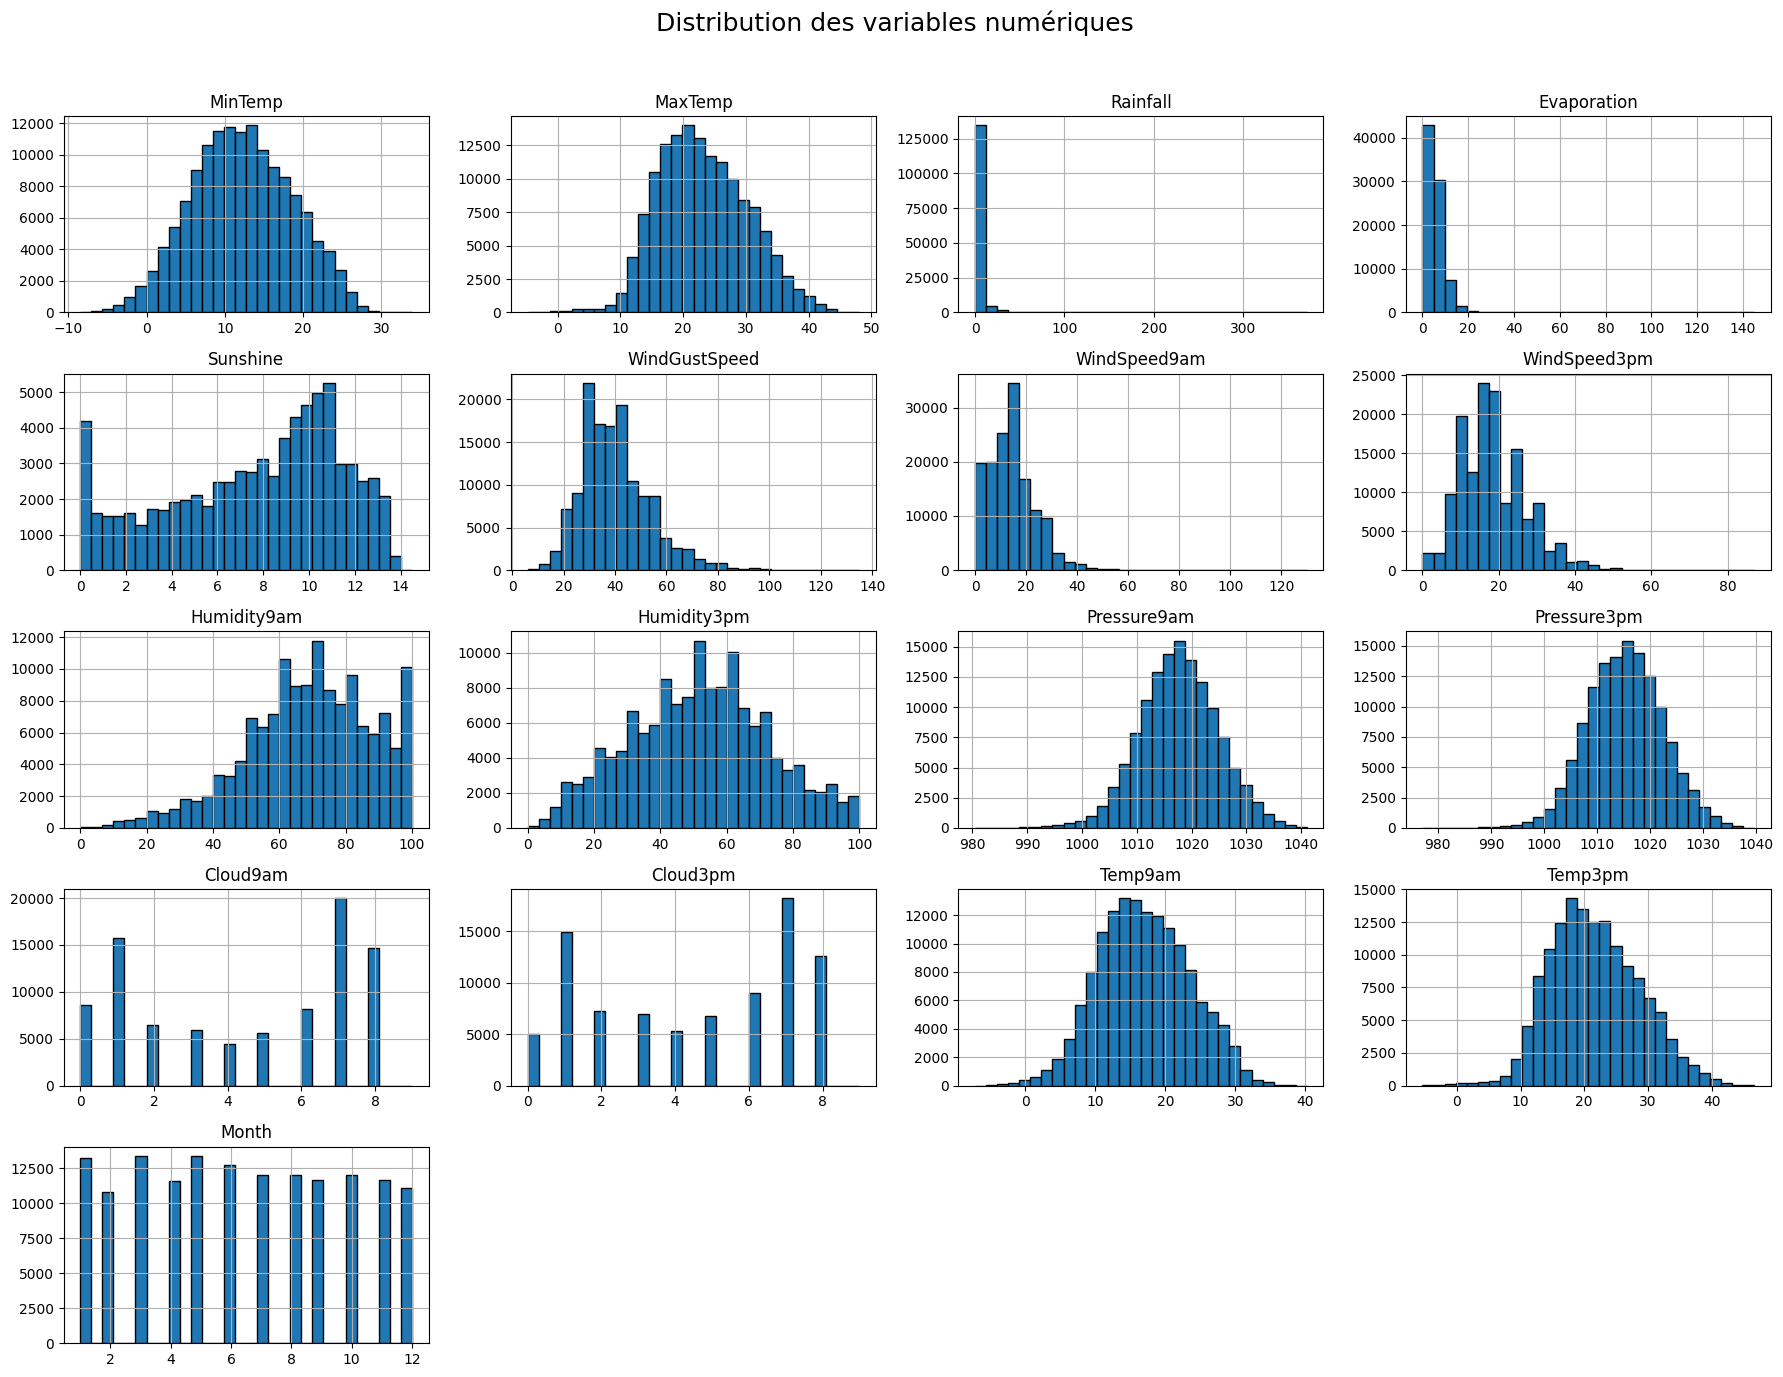

In [5]:
num_cols = df.select_dtypes(include="number").columns

df[num_cols].hist(
    figsize=(18,14),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution des variables numériques", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Distribution des variables qualitatives **

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
       'RainTomorrow'],
      dtype='object')


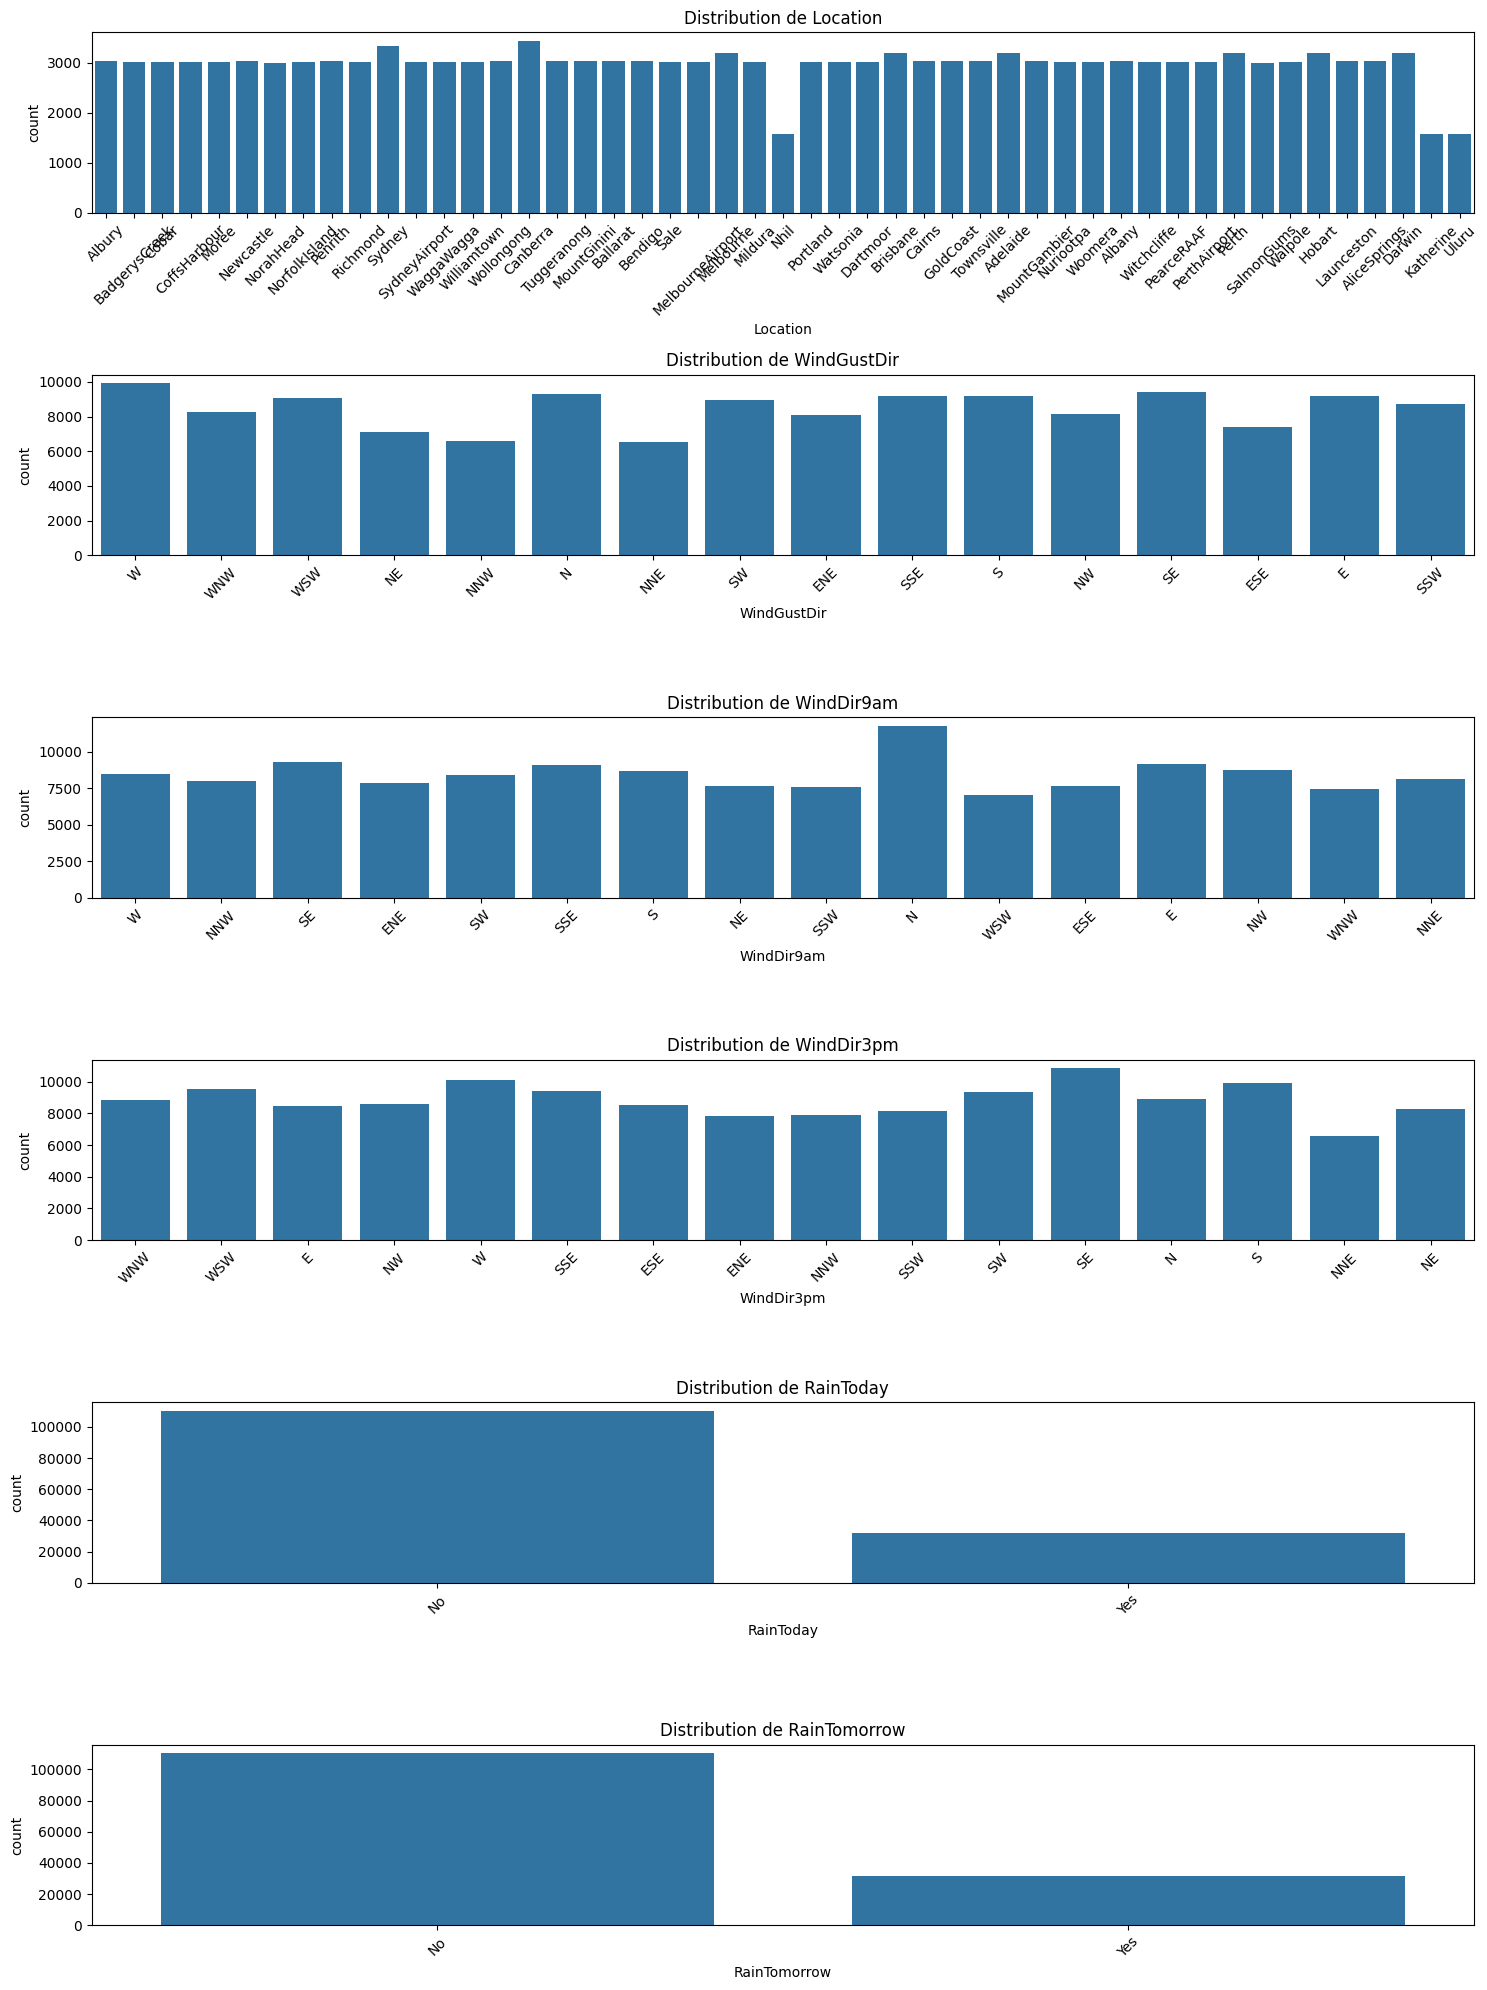

In [7]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop("Date", errors="ignore")
print(cat_cols)
plt.figure(figsize=(15,20))

for i, col in enumerate(cat_cols):
    plt.subplot(len(cat_cols), 1, i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution de {col}")

plt.tight_layout()
plt.show()


**Encodage des variables qualitatives **

In [8]:
df = df.dropna(subset=["RainTomorrow"])
df["RainTomorrow"] = df["RainTomorrow"].map({"No":0, "Yes":1})
df["RainToday"] = df["RainToday"].map({"No":0, "Yes":1})
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print(df.shape)

(142193, 24)


In [9]:
corr_matrix = df.corr()
corr_target = corr_matrix["RainTomorrow"].sort_values(ascending=False)

print(corr_target)


RainTomorrow     1.000000
Humidity3pm      0.446160
Cloud3pm         0.381870
Cloud9am         0.317380
RainToday        0.313097
Humidity9am      0.257161
Rainfall         0.239032
WindGustSpeed    0.234010
WindSpeed9am     0.090995
WindSpeed3pm     0.087817
MinTemp          0.083936
WindGustDir      0.054488
WindDir3pm       0.034435
WindDir9am       0.018436
Month            0.007328
Location        -0.003579
Date            -0.011256
Temp9am         -0.025691
Evaporation     -0.119285
MaxTemp         -0.159237
Temp3pm         -0.192424
Pressure3pm     -0.226031
Pressure9am     -0.246371
Sunshine        -0.450768
Name: RainTomorrow, dtype: float64


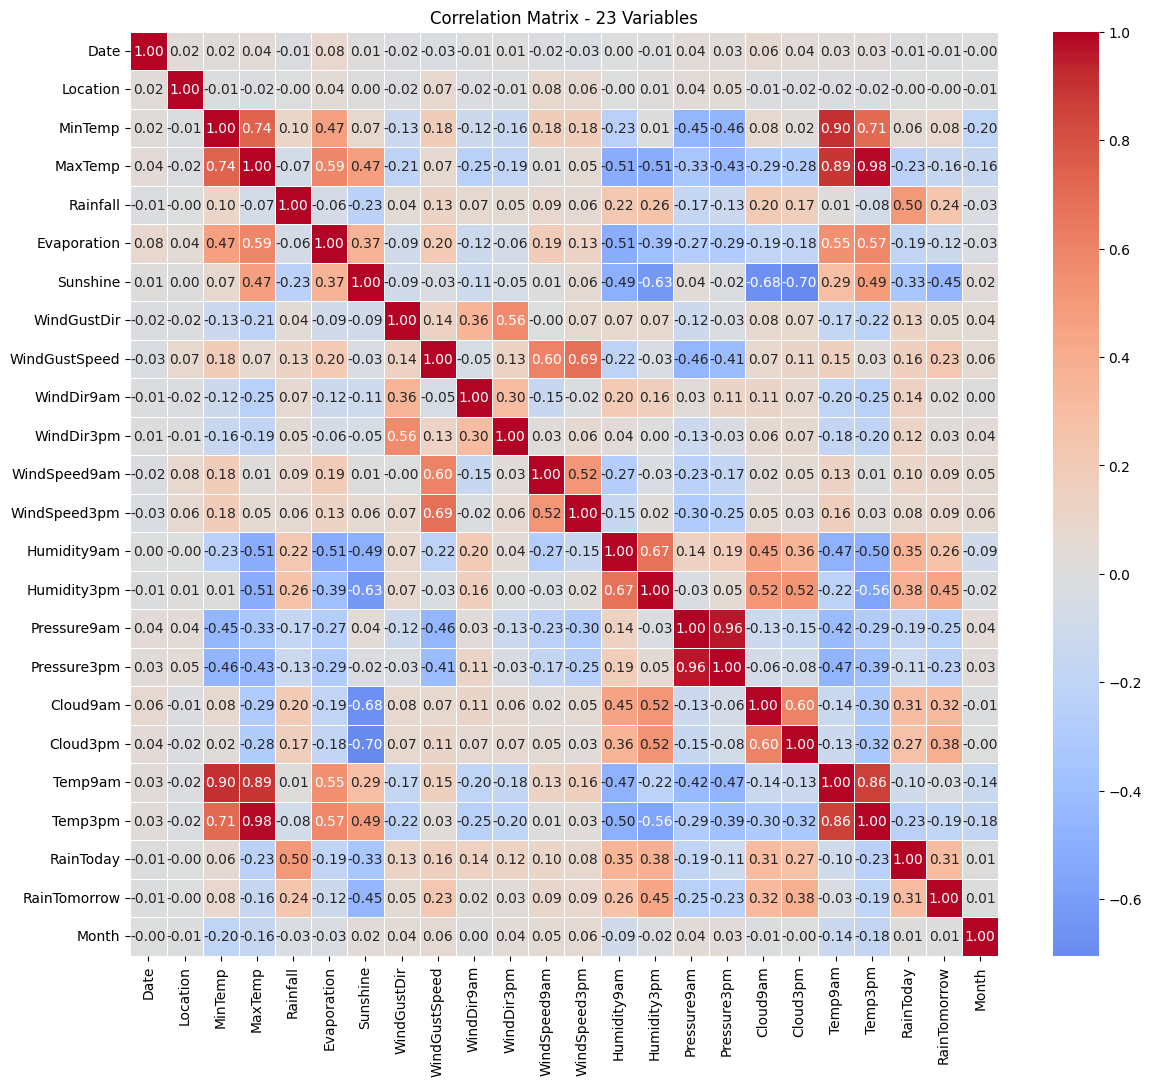

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix - 23 Variables")
plt.show()


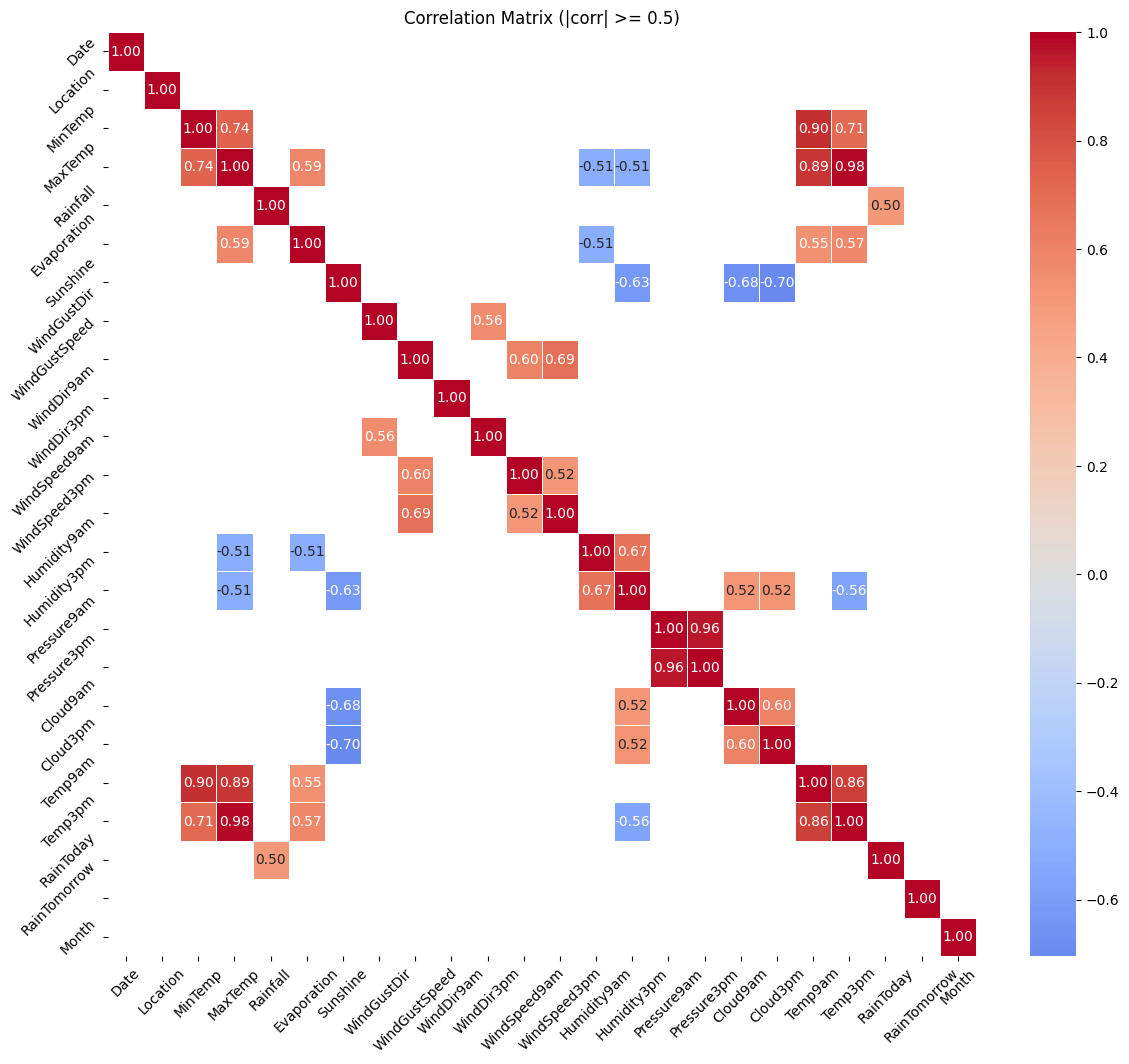

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


corr_filtered = corr_matrix.copy()


corr_filtered[abs(corr_filtered) < 0.5] = np.nan

plt.figure(figsize=(14,12))

sns.heatmap(
    corr_filtered,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (|corr| >= 0.5)")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()


**Nettoyage de valeurs Manquantes **

In [12]:
missing_values = df.isnull().sum()

print(missing_values)


Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir          0
WindGustSpeed     9270
WindDir9am           0
WindDir3pm           0
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
Month                0
dtype: int64


In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0]

print(missing_percent.sort_values(ascending=False))


Sunshine         47.692924
Evaporation      42.789026
Cloud3pm         40.152469
Cloud9am         37.735332
Pressure9am       9.855619
Pressure3pm       9.832411
WindGustSpeed     6.519308
Humidity3pm       2.538803
Temp3pm           1.917113
WindSpeed3pm      1.849599
Humidity9am       1.247600
RainToday         0.988797
Rainfall          0.988797
WindSpeed9am      0.948007
Temp9am           0.635756
MinTemp           0.447983
MaxTemp           0.226453
dtype: float64


In [14]:
# Sélection des colonnes à supprimer (> 10%)
cols_to_drop = missing_percent[missing_percent > 10].index

print("Colonnes supprimées (>10% missing) :")
print(cols_to_drop)

# Suppression
df = df.drop(columns=cols_to_drop)

print("\nNouvelle dimension du dataset :", df.shape)


Colonnes supprimées (>10% missing) :
Index(['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], dtype='object')

Nouvelle dimension du dataset : (142193, 20)


In [15]:
missing_per_row = df.isnull().sum(axis=1)

print(missing_per_row.value_counts().sort_index())


0     119590
1       4916
2      12052
3       2379
4       1154
5        700
6        878
7        240
8         60
9         33
10        99
11        70
12        16
13         6
Name: count, dtype: int64


In [16]:
# Nombre total de lignes
total_rows = len(df)
print("Nombre total de lignes :", total_rows)

# Lignes avec >= 5 valeurs manquantes
rows_more_5 = df[df.isnull().sum(axis=1) >= 5]

num_rows_more_5 = len(rows_more_5)

print("Nombre de lignes avec ≥ 5 NaN :", num_rows_more_5)

# Calcul du pourcentage
percentage = (num_rows_more_5 / total_rows) * 100

print(f"Pourcentage de lignes avec ≥ 5 NaN : {percentage:.2f}%")



Nombre total de lignes : 142193
Nombre de lignes avec ≥ 5 NaN : 2102
Pourcentage de lignes avec ≥ 5 NaN : 1.48%


In [17]:
df = df[df.isnull().sum(axis=1) < 5]

print("Nouvelle taille :", df.shape)


Nouvelle taille : (140091, 20)


In [22]:
print(df.dtypes)
X = df.drop(columns=["RainTomorrow", "Date"])
y = df["RainTomorrow"]

Date             datetime64[ns]
Location                  int64
MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
WindGustDir               int64
WindGustSpeed           float64
WindDir9am                int64
WindDir3pm                int64
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Temp9am                 float64
Temp3pm                 float64
RainToday               float64
RainTomorrow              int64
Month                     int32
dtype: object


**Imputation KNN**

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

binary_cols = ["RainToday"]  # tes colonnes binaires
num_cols = X.columns.difference(binary_cols)

# scaler + KNN seulement sur numériques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])

imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)
X_imputed = scaler.inverse_transform(X_imputed)

X_num_imputed = pd.DataFrame(X_imputed, columns=num_cols, index=X.index)

# concat avec binaires NON modifiées
df_imputed = pd.concat([X_num_imputed, X[binary_cols],y], axis=1)
df_imputed["RainToday"] = df_imputed["RainToday"].fillna(0)
print("Total NaN après imputation :", df_imputed.isnull().sum().sum())
df_imputed["Month"] = df["Month"].values

Total NaN après imputation : 0


In [25]:
df_imputed.head(10)

,Humidity3pm,Humidity9am,Location,MaxTemp,MinTemp,Month,Pressure3pm,Pressure9am,Rainfall,Temp3pm,Temp9am,WindDir3pm,WindDir9am,WindGustDir,WindGustSpeed,WindSpeed3pm,WindSpeed9am,RainToday,RainTomorrow
0,22.0,71.0,2.0,22.9,13.4,12,1007.1,1007.7,0.6,21.8,16.9,14.0,13.0,13.0,44.0,24.0,20.0,0.0,0
1,25.0,44.0,2.0,25.1,7.4,12,1007.8,1010.6,0.0,24.3,17.2,15.0,6.0,14.0,44.0,22.0,4.0,0.0,0
2,30.0,38.0,2.0,25.7,12.9,12,1008.7,1007.6,0.0,23.2,21.0,15.0,13.0,15.0,46.0,26.0,19.0,0.0,0
3,16.0,45.0,2.0,28.0,9.2,12,1012.8,1017.6,0.0,26.5,18.1,0.0,9.0,4.0,24.0,9.0,11.0,0.0,0
4,33.0,82.0,2.0,32.3,17.5,12,1006.0,1010.8,1.0,29.7,17.8,7.0,1.0,13.0,41.0,20.0,7.0,0.0,0
5,23.0,55.0,2.0,29.7,14.6,12,1005.4,1009.2,0.2,28.9,20.6,13.0,13.0,14.0,56.0,24.0,19.0,0.0,0
6,19.0,49.0,2.0,25.0,14.3,12,1008.2,1009.6,0.0,24.6,18.1,13.0,12.0,13.0,50.0,24.0,20.0,0.0,0
7,19.0,48.0,2.0,26.7,7.7,12,1010.1,1013.4,0.0,25.5,16.3,13.0,10.0,13.0,35.0,17.0,6.0,0.0,0
8,9.0,42.0,2.0,31.9,9.7,12,1003.6,1008.9,0.0,30.2,18.3,7.0,9.0,6.0,80.0,28.0,7.0,0.0,1
9,27.0,58.0,2.0,30.1,13.1,12,1005.7,1007.0,1.4,28.2,20.1,10.0,8.0,13.0,28.0,11.0,15.0,1.0,0


**Vérification  du déséquilibre des classes**

In [26]:
print("Répartition finale des classes :")
print(df_imputed["RainTomorrow"].value_counts())

print("\nPourcentage :")
print(df_imputed["RainTomorrow"].value_counts(normalize=True) * 100)

Répartition finale des classes :
RainTomorrow
0    108782
1     31309
Name: count, dtype: int64

Pourcentage :
RainTomorrow
0    77.650955
1    22.349045
Name: proportion, dtype: float64


**Analyse conditionnelle: les différences entre pluie / pas pluie.**

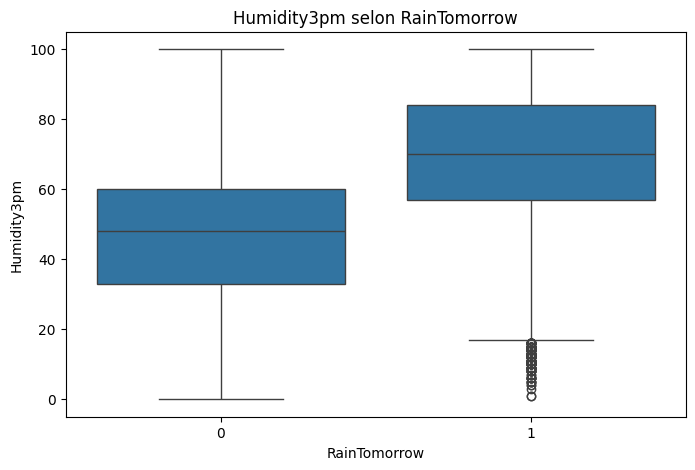

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x="RainTomorrow", y="Humidity3pm", data=df_imputed)
plt.title("Humidity3pm selon RainTomorrow")
plt.show()

L’humidité à 15h est significativement plus élevée les jours précédant un épisode de pluie.
La médiane d’humidité passe d’environ 48% pour les jours secs à près de 70% pour les jours pluvieux.
Cela confirme que l’humidité est un facteur déterminant dans la formation des précipitations.

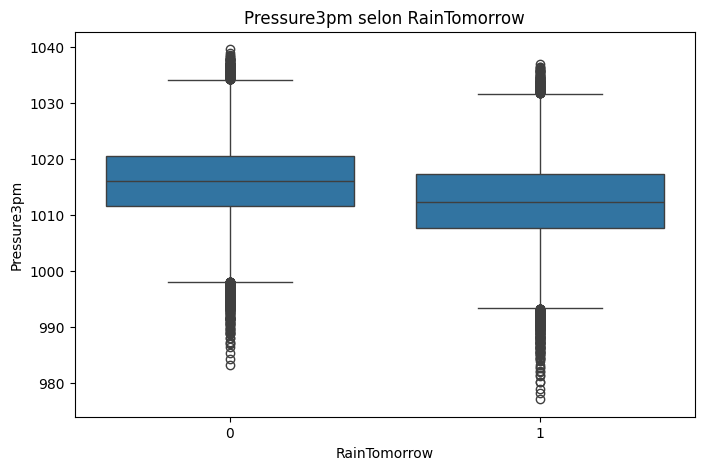

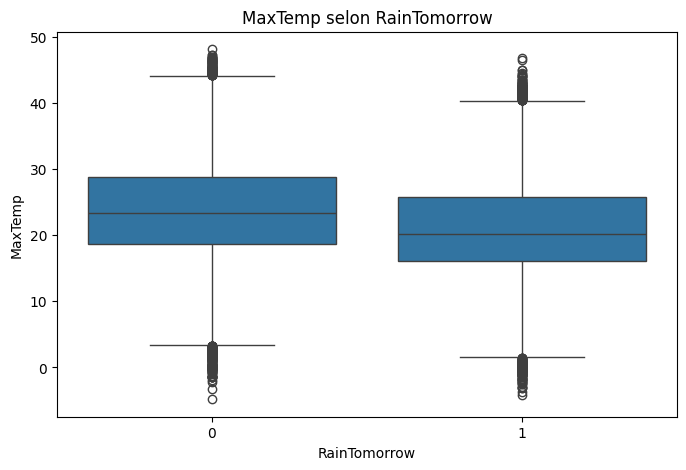

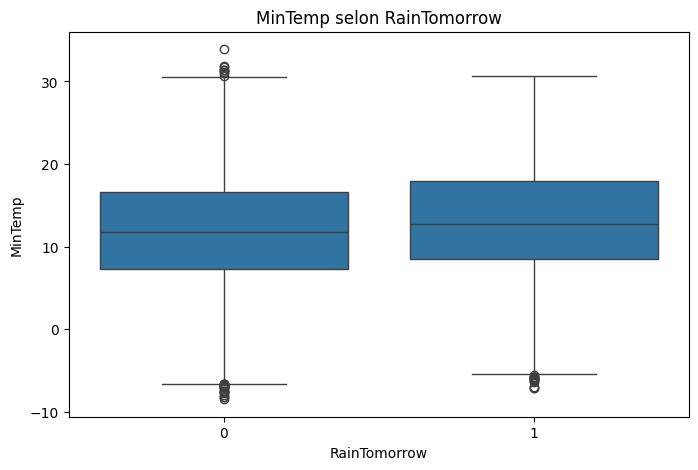

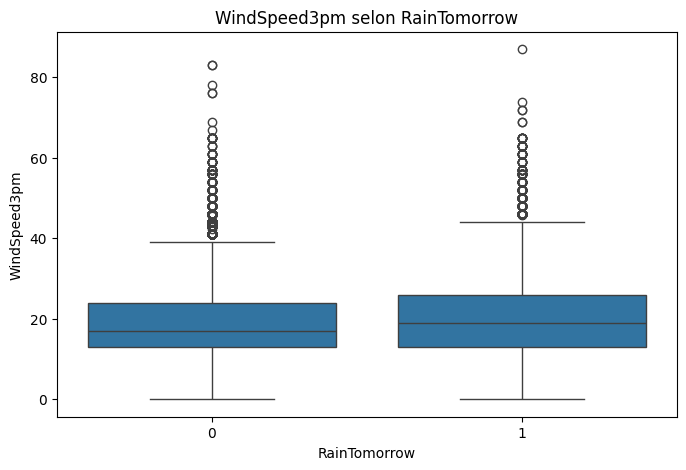

In [28]:
variables_to_check = ["Pressure3pm", "MaxTemp", "MinTemp", "WindSpeed3pm"]

for var in variables_to_check:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="RainTomorrow", y=var, data=df_imputed)
    plt.title(f"{var} selon RainTomorrow")
    plt.show()

# **Saisonnalité **

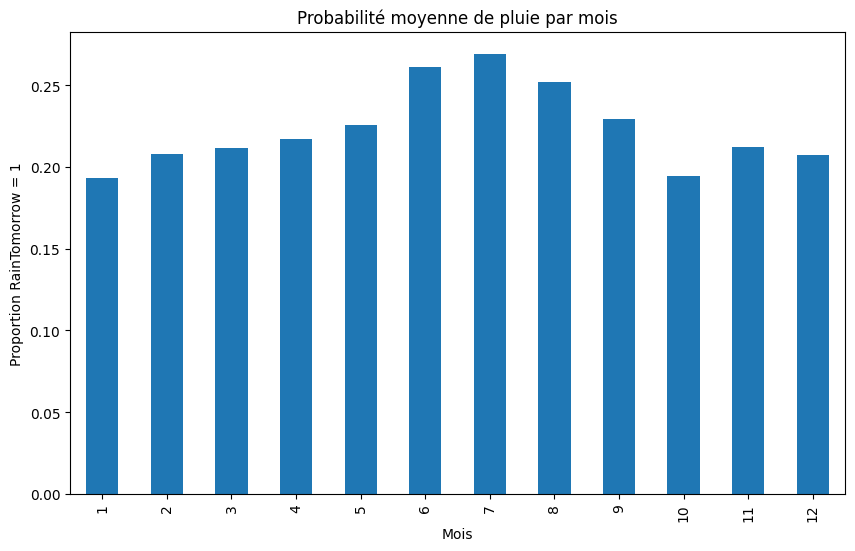

In [29]:
rain_by_month = df_imputed.groupby("Month")["RainTomorrow"].mean()

plt.figure(figsize=(10,6))
rain_by_month.plot(kind="bar")
plt.title("Probabilité moyenne de pluie par mois")
plt.ylabel("Proportion RainTomorrow = 1")
plt.xlabel("Mois")
plt.show()

# **Feature Engineering**

Amplitude thermique :Une grande variation thermique peut favoriser l’instabilité atmosphérique.

In [30]:
df_imputed["TempRange"] = df_imputed["MaxTemp"] - df_imputed["MinTemp"]

Variation d’humidité:Si l’humidité augmente dans la journée → condensation probable

In [31]:
df_imputed["HumidityDiff"] = df_imputed["Humidity3pm"] - df_imputed["Humidity9am"]

Variation de pression:Une baisse de pression annonce souvent un front pluvieux.

In [32]:
df_imputed["PressureDiff"] = df_imputed["Pressure3pm"] - df_imputed["Pressure9am"]

Vérifier si ces nouvelles variables sont utiles

In [44]:
df_imputed.head()

,Humidity3pm,Humidity9am,Location,MaxTemp,MinTemp,Month,Pressure3pm,Pressure9am,Rainfall,Temp3pm,...,WindDir9am,WindGustDir,WindGustSpeed,WindSpeed3pm,WindSpeed9am,RainToday,RainTomorrow,TempRange,HumidityDiff,PressureDiff
0,22.0,71.0,2.0,22.9,13.4,12,1007.1,1007.7,0.6,21.8,...,13.0,13.0,44.0,24.0,20.0,0.0,0,9.5,-49.0,-0.6
1,25.0,44.0,2.0,25.1,7.4,12,1007.8,1010.6,0.0,24.3,...,6.0,14.0,44.0,22.0,4.0,0.0,0,17.7,-19.0,-2.8
2,30.0,38.0,2.0,25.7,12.9,12,1008.7,1007.6,0.0,23.2,...,13.0,15.0,46.0,26.0,19.0,0.0,0,12.8,-8.0,1.1
3,16.0,45.0,2.0,28.0,9.2,12,1012.8,1017.6,0.0,26.5,...,9.0,4.0,24.0,9.0,11.0,0.0,0,18.8,-29.0,-4.8
4,33.0,82.0,2.0,32.3,17.5,12,1006.0,1010.8,1.0,29.7,...,1.0,13.0,41.0,20.0,7.0,0.0,0,14.8,-49.0,-4.8


In [45]:
corr_new = df_imputed.corr()["RainTomorrow"].sort_values(ascending=False)
print(corr_new.head(25))

RainTomorrow     1.000000
Humidity3pm      0.445170
RainToday        0.307089
HumidityDiff     0.267030
Humidity9am      0.256823
Rainfall         0.237340
WindGustSpeed    0.225389
WindSpeed9am     0.091120
WindSpeed3pm     0.088040
MinTemp          0.085258
PressureDiff     0.084891
WindGustDir      0.055234
WindDir3pm       0.034027
WindDir9am       0.017691
Month            0.007489
Location        -0.003270
Temp9am         -0.026030
MaxTemp         -0.158245
Temp3pm         -0.192236
Pressure3pm     -0.222023
Pressure9am     -0.243150
TempRange       -0.337027
Name: RainTomorrow, dtype: float64


variable : saison

SeasonName
Autumn    0.218173
Spring    0.211645
Summer    0.202183
Winter    0.260710
Name: RainTomorrow, dtype: float64


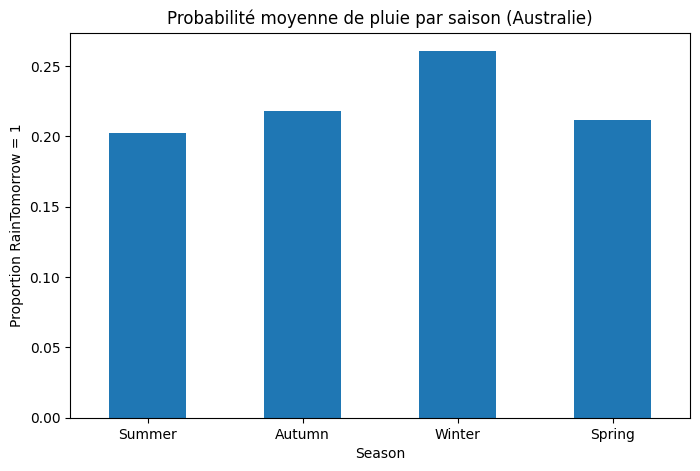

In [46]:
def get_season(month):
    if month in [12,1,2]:
        return 1  # Été australien
    elif month in [3,4,5]:
        return 2  # Automne
    elif month in [6,7,8]:
        return 3  # Hiver
    else:
        return 4  # Printemps

df_imputed["Season"] = df_imputed["Month"].apply(get_season)
season_map = {
    1: "Summer",
    2: "Autumn",
    3: "Winter",
    4: "Spring"
}

df_imputed["SeasonName"] = df_imputed["Season"].map(season_map)
rain_by_season = df_imputed.groupby("SeasonName")["RainTomorrow"].mean()

print(rain_by_season)
plt.figure(figsize=(8,5))

# Pour garder l'ordre logique des saisons
rain_by_season = rain_by_season.reindex(["Summer", "Autumn", "Winter", "Spring"])

rain_by_season.plot(kind="bar")

plt.title("Probabilité moyenne de pluie par saison (Australie)")
plt.ylabel("Proportion RainTomorrow = 1")
plt.xlabel("Season")
plt.xticks(rotation=0)

plt.show()

In [ ]:
le = LabelEncoder()

df_imputed["Season"] = le.fit_transform(df_imputed["Season"])


In [47]:
#Sauvegarde fichier nettoyé
df_imputed.to_csv('weatherAUS_ForModel.csv', index=False)